In [1]:
from logreg.logreg import LogisticRegression
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

%load_ext autoreload
%autoreload 2

In [2]:
# 1. Generate a simple, easily separable dataset with 2 features
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

# Reshape y to match your model's expected (n_samples x 1) shape
y = y.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Instantiate and train your model
model = LogisticRegression(n_features=X.shape[1], seed=42)
model.fit(X_train, y_train, learning_rate=0.03, batch_size=50, epochs=100)

# 3. Evaluate
predictions = model.predict(X_test)
accuracy = np.mean(predictions == y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 88.00%


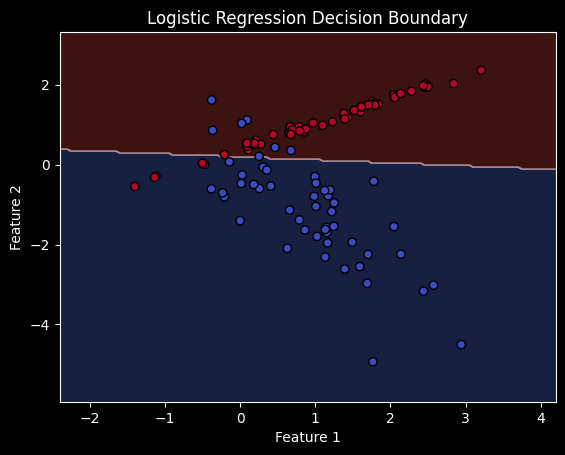

In [3]:
x_min, x_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
y_min, y_max = X_test[:, 1].min() - 1, X_test[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Flatten grid to predict
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points)
Z = Z.reshape(xx.shape)

# Plot contour and scatter
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test.ravel(), edgecolors='k', cmap=plt.cm.coolwarm)

plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()